# Basemap Chart

A basemap chart draws the land under a chart whose x and y are longitude and latitude: coastlines, a land fill, the borders between countries and the large lakes. The outlines are the [Natural Earth](https://www.naturalearthdata.com) 1:110m set (public domain), and they ship with the package, so a map needs no download, no extra dependency and no picture made somewhere else. On its own it is a map with axes; its use is underneath another chart, so that the marks sit on the coast they describe: epicentres, weather stations, a ship's track. This guide shows how to create basemap charts with the [datachart.charts.BasemapChart](../../../references/charts/basemapchart/#datachart.charts.BasemapChart) function and how to compose them with other charts, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-basemap-chart), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import BasemapChart, ScatterChart
from datachart.utils import Panel

## Basics

The examples in this guide share one dataset: the 54 earthquakes of magnitude 5 and above that struck the Aegean and Anatolia in 2023, from the [USGS earthquake catalogue](https://earthquake.usgs.gov/fdsnws/event/1/) (public domain). The hidden cell below holds them. `QUAKES` is one tuple per earthquake: the hours since the start of 2023, the latitude, the longitude, the depth in kilometres, and the magnitude.

In [2]:
# USGS earthquake catalogue (public domain), magnitude 5 and above, 2023:
# (hours since 2023-01-01 UTC, latitude, longitude, depth in km, magnitude)
QUAKES = [
    (418.137, 38.433, 44.946, 19.1, 5.7),
    (588.618, 35.709, 28.497, 29.6, 5.9),
    (666.246, 38.42, 44.91, 16.0, 5.9),
    (666.282, 38.481, 44.928, 10.0, 5.1),
    (865.293, 37.226, 37.014, 10.0, 7.8),
    (865.447, 37.225, 37.0, 10.0, 5.7),
    (865.471, 37.189, 36.893, 9.8, 6.7),
    (865.608, 36.992, 36.683, 10.0, 5.6),
    (865.973, 37.03, 36.621, 10.0, 5.1),
    (866.06, 37.771, 37.914, 16.9, 5.3),
    (866.107, 37.923, 38.061, 10.0, 5.0),
    (866.387, 37.182, 36.966, 11.4, 5.3),
    (868.313, 38.184, 38.534, 16.4, 5.0),
    (874.414, 38.011, 37.196, 7.4, 7.5),
    (874.446, 38.032, 38.098, 10.0, 6.0),
    (874.536, 37.996, 37.203, 14.1, 5.4),
    (874.599, 38.025, 37.802, 10.0, 5.8),
    (874.859, 38.248, 38.185, 10.0, 5.7),
    (875.093, 38.075, 36.759, 6.0, 5.1),
    (876.036, 38.058, 36.511, 8.5, 6.0),
    (877.129, 38.038, 37.371, 16.9, 5.0),
    (877.657, 38.017, 37.701, 10.0, 5.3),
    (877.748, 37.941, 37.492, 16.9, 5.0),
    (879.559, 38.19, 38.176, 7.4, 5.4),
    (880.725, 38.001, 36.508, 10.0, 5.0),
    (882.065, 37.978, 36.446, 10.0, 5.2),
    (884.631, 37.251, 37.086, 10.0, 5.3),
    (891.22, 37.764, 37.731, 10.0, 5.5),
    (895.188, 38.097, 38.64, 9.1, 5.4),
    (898.304, 38.016, 38.57, 13.0, 5.3),
    (903.815, 37.994, 36.477, 11.1, 5.0),
    (906.167, 37.936, 36.601, 17.9, 5.3),
    (919.809, 38.006, 36.496, 10.0, 5.0),
    (923.198, 37.939, 37.661, 9.6, 5.4),
    (926.34, 37.996, 37.432, 5.4, 5.1),
    (1024.497, 38.824, 38.031, 10.0, 5.0),
    (1123.797, 36.177, 35.797, 10.0, 5.2),
    (1171.525, 38.07, 36.599, 12.2, 5.0),
    (1217.075, 36.162, 36.025, 16.0, 6.3),
    (1217.127, 36.159, 35.935, 10.0, 5.5),
    (1330.453, 37.98, 33.988, 11.8, 5.2),
    (1377.081, 38.214, 38.277, 10.0, 5.2),
    (1466.895, 37.84, 36.7, 7.1, 5.0),
    (1744.6, 35.517, 22.179, 10.0, 5.4),
    (1953.332, 38.011, 36.427, 10.0, 5.3),
    (1971.282, 38.461, 44.85, 11.0, 5.6),
    (2780.01, 36.429, 26.316, 116.5, 5.1),
    (3306.981, 34.992, 24.849, 10.8, 5.1),
    (4925.748, 37.579, 35.948, 13.1, 5.5),
    (5321.8, 38.267, 38.201, 10.0, 5.2),
    (5383.825, 35.279, 23.851, 10.0, 5.1),
    (7350.444, 38.686, 23.558, 10.4, 5.1),
    (7838.769, 38.084, 38.552, 10.0, 5.3),
    (8095.706, 40.437, 28.848, 10.1, 5.1),
]

The first three earthquakes of the year:

In [3]:
QUAKES[:3]

[(418.137, 38.433, 44.946, 19.1, 5.7),
 (588.618, 35.709, 28.497, 29.6, 5.9),
 (666.246, 38.42, 44.91, 16.0, 5.9)]

**Basic example.** A basemap chart needs no data: called with no arguments it draws the coastline and the land of the whole world, longitude on x and latitude on y. Nothing is projected: a degree is a degree on both axes, which is what lets the marks of any other chart land in the right place without a transform.

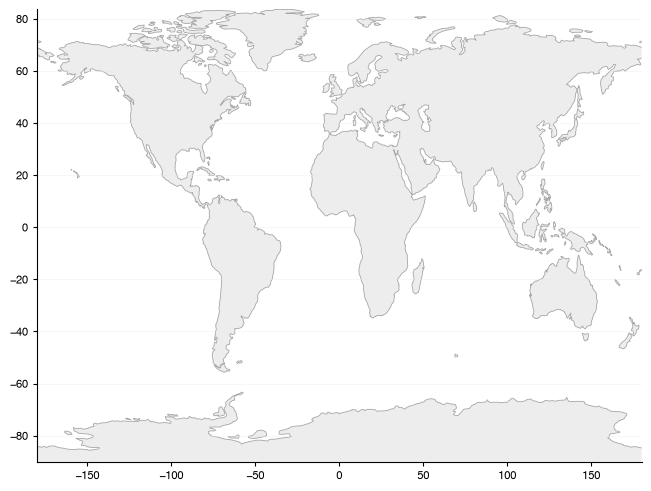

In [4]:
BasemapChart().show()

## Customizing the Basemap Chart

Every customization is either a keyword argument of `BasemapChart` or a `plot_basemap_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                        | See |
| :------------------------------------------ | :--------------------------------------------------------- | :-- |
| choose coastlines, land, borders or lakes   | `features`                                                 | [Features](#features) |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel`                                | [Title, axis labels and limits](#title-axis-labels-and-limits) |
| show one region                             | `xmin`, `xmax`, `ymin`, `ymax`                             | [Title, axis labels and limits](#title-axis-labels-and-limits) |
| keep the region at its true proportions     | `aspect_ratio="geographic"`                                | [Geographic aspect](#geographic-aspect) |
| change the figure size or add a graticule   | `figsize`, `show_grid`                                     | [Figure size and grid](#figure-size-and-grid) |
| recolor the land, the lines or the lakes    | `style={"plot_basemap_...": ...}`                          | [Colors and lines](#colors-and-lines) |
| draw my own outlines                        | `geometry`                                                 | [Your own outlines](#your-own-outlines) |
| put the map under or over other charts      | `position`, `Panel`                                        | [Composing with Panel](#composing-with-panel) |
| save the chart as an image                  | `save_figure`                                              | [Saving figures](../../utility/saving/) |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `features` | [`BASEMAP_FEATURE`](../../../references/constants/#datachart.constants.BASEMAP_FEATURE) |
| `position` | [`DRAW_POSITION`](../../../references/constants/#datachart.constants.DRAW_POSITION) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `aspect_ratio` | [`ASPECT_RATIO`](../../../references/constants/#datachart.constants.ASPECT_RATIO) |

The outline keys of `geometry` are listed in [BasemapDataAttrs](../../../references/charts/basemapchart/#datachart.typings.BasemapDataAttrs), the style attributes in [BasemapStyleAttrs](../../../references/charts/basemapchart/#datachart.typings.BasemapStyleAttrs).

### Features

A map should carry only what the reader needs to find their way, and which outlines those are depends on the question. `features` takes one [BASEMAP_FEATURE](../../../references/constants/#datachart.constants.BASEMAP_FEATURE) member or a list of them: `COASTLINE` and `LAND` by default, `BORDERS` for the lines between countries, and `LAKES` for the large lakes, filled with the axes background so they read as water. The ocean is not a feature: it is the background the land sits on. Below, Europe with its land, borders and lakes: the lakes of Russia and Finland and the Caspian read as the sea does.

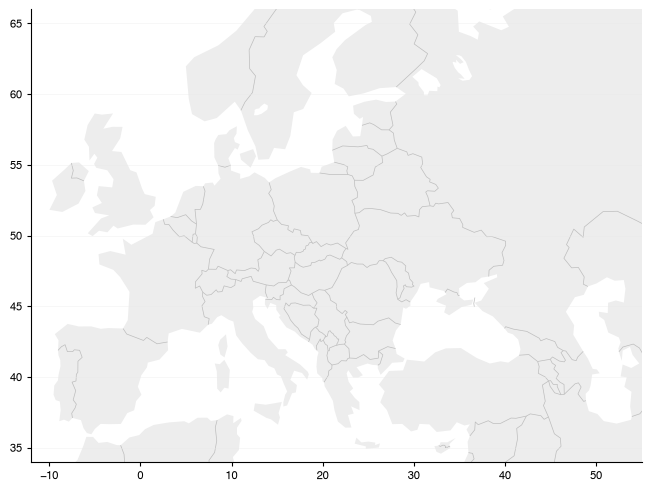

In [5]:
from datachart.constants import BASEMAP_FEATURE

BasemapChart(
    [BASEMAP_FEATURE.LAND, BASEMAP_FEATURE.BORDERS, BASEMAP_FEATURE.LAKES],
    # Europe, from the Atlantic to the Caspian
    xmin=-12,
    xmax=55,
    ymin=34,
    ymax=66,
).show()

### Title, axis labels and limits

A map with bare numbers on its axes leaves the reader to guess the units. `title`, `xlabel` and `ylabel` name them. On its own the chart frames the whole world, and `xmin`, `xmax`, `ymin` and `ymax` narrow it to the region the report is about, here the Aegean and Anatolia, where the earthquakes of this guide struck.

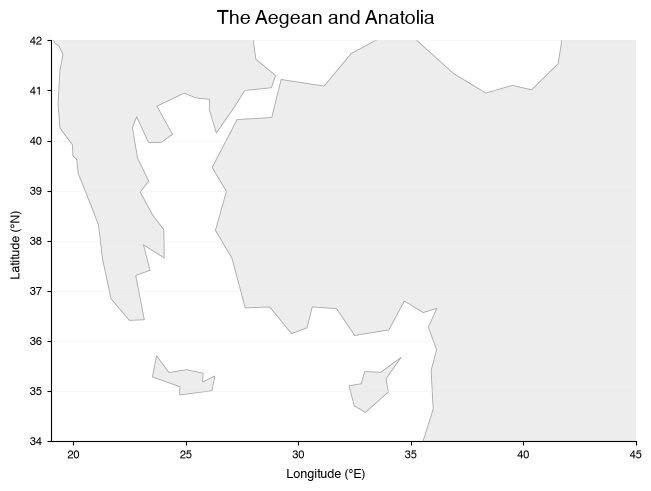

In [6]:
BasemapChart(
    title="The Aegean and Anatolia",
    xlabel="Longitude (°E)",
    ylabel="Latitude (°N)",
    xmin=19,
    xmax=45,
    ymin=34,
    ymax=42,
).show()

### Geographic aspect

Longitude and latitude drawn straight stretch a region sideways: away from the equator a degree of longitude covers fewer kilometres than a degree of latitude, so Scandinavia on default axes comes out squat and wide. `aspect_ratio` takes an [ASPECT_RATIO](../../../references/constants/#datachart.constants.ASPECT_RATIO) member, and `ASPECT_RATIO.GEOGRAPHIC` narrows each degree of longitude by the cosine of the latitude in the middle of the y-axis, so the region keeps its proportions. It is not a projection, and at the scale of a region the difference does not show. It is not only for the basemap either: every chart that takes `aspect_ratio` accepts it, and so does `Panel`. The y-axis has to stay within -90 and 90, since it is read as latitude.

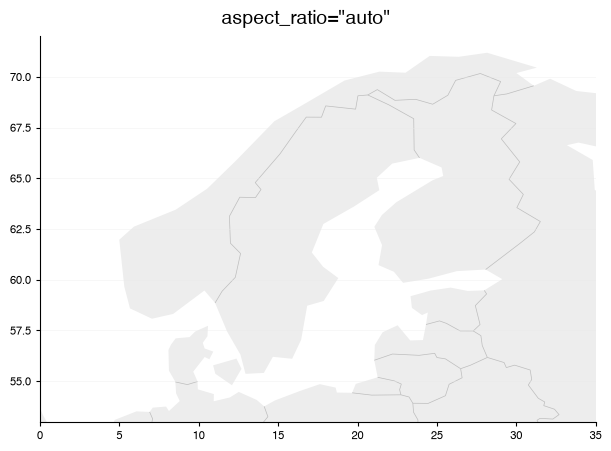

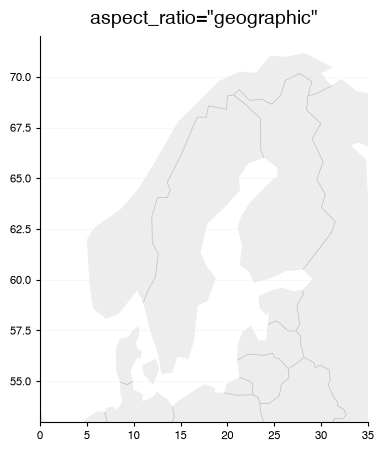

In [7]:
from datachart.constants import ASPECT_RATIO

SCANDINAVIA = {"xmin": 0, "xmax": 35, "ymin": 53, "ymax": 72}
for aspect in [ASPECT_RATIO.AUTO, ASPECT_RATIO.GEOGRAPHIC]:
    BasemapChart(
        [BASEMAP_FEATURE.LAND, BASEMAP_FEATURE.BORDERS],
        title=f'aspect_ratio="{aspect}"',
        aspect_ratio=aspect,
        figsize=(6.0, 4.4),
        **SCANDINAVIA,
    ).show()

### Figure size and grid

The region of this guide is three times as wide as it is tall, so the default, nearly square figure leaves most of its area empty. `figsize` takes a `(width, height)` tuple in inches or a preset from [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE). `show_grid` takes a [SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) member; the grid draws over the land, so it reads as the graticule of the map.

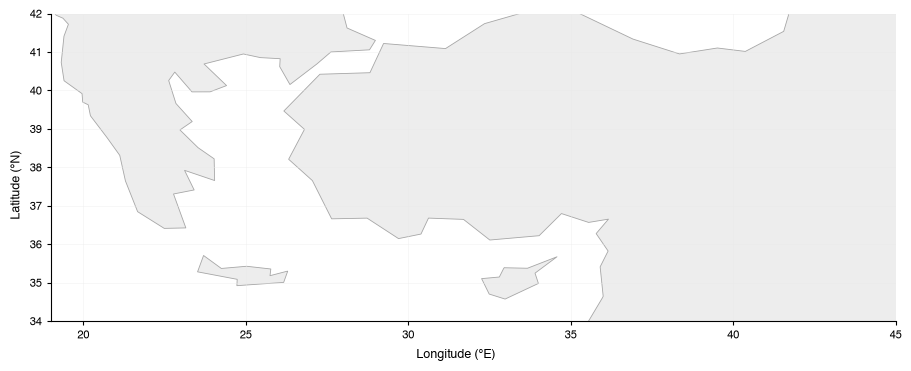

In [8]:
from datachart.constants import SHOW_GRID

REGION = {"xmin": 19, "xmax": 45, "ymin": 34, "ymax": 42}
BasemapChart(
    xlabel="Longitude (°E)",
    ylabel="Latitude (°N)",
    # a wide figure for a wide region, and a graticule over the land
    figsize=(9.0, 3.6),
    show_grid=SHOW_GRID.BOTH,
    **REGION,
).show()

### Colors and lines

The map is furniture, not data, so the theme draws it in muted greys that stay behind whatever is composed over it. When a figure needs another look, the `plot_basemap_*` style attributes set it: `plot_basemap_land_color`, `plot_basemap_coastline_color` and `plot_basemap_coastline_width`, `plot_basemap_border_color`, `plot_basemap_border_width` and `plot_basemap_border_style`, and `plot_basemap_lake_color`. Below, a sand-colored land with blue-grey water lines and dashed borders.

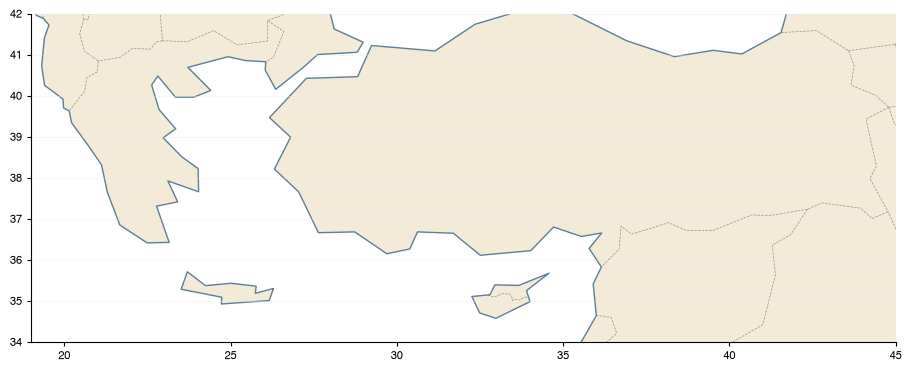

In [9]:
BasemapChart(
    [BASEMAP_FEATURE.LAND, BASEMAP_FEATURE.COASTLINE, BASEMAP_FEATURE.BORDERS],
    style={
        "plot_basemap_land_color": "#f3ead8",
        "plot_basemap_coastline_color": "#5b7f95",
        "plot_basemap_coastline_width": 1.0,
        "plot_basemap_border_color": "#9a8f7a",
        "plot_basemap_border_style": "--",
    },
    figsize=(9.0, 3.6),
    **REGION,
).show()

### Your own outlines

The bundled outlines suit a continent or a region; at the scale of a city they are too coarse, and some maps are not of the Earth at all. `geometry` takes your own outlines in place of the bundled ones: a `{"lon", "lat", "feature"}` dictionary, or a list of them. `lon` and `lat` run along one outline after another, with a `NaN` between two outlines, and `feature` says how they are drawn: `"coastline"` and `"borders"` as lines, `"land"` and `"lakes"` as filled areas, each in its own style. A ring inside a filled area that runs the other way round is a hole. The site plan below is illustrative, in metres rather than degrees: the building is land, its courtyard a hole, and the paths are drawn as borders.

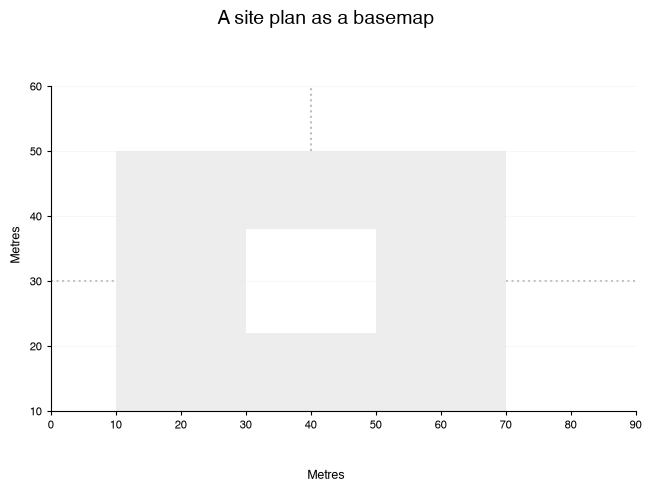

In [10]:
nan = float("nan")
building = {
    # the footprint anticlockwise, then the courtyard clockwise: a hole
    "lon": [10, 70, 70, 10, nan, 30, 30, 50, 50],
    "lat": [10, 10, 50, 50, nan, 22, 38, 38, 22],
    "feature": "land",
}
paths = {
    "lon": [0, 10, nan, 70, 90, nan, 40, 40],
    "lat": [30, 30, nan, 30, 30, nan, 50, 60],
    "feature": "borders",
}

BasemapChart(
    geometry=[building, paths],
    title="A site plan as a basemap",
    xlabel="Metres",
    ylabel="Metres",
    style={"plot_basemap_border_style": ":", "plot_basemap_border_width": 1.5},
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

## Composing with Panel

A basemap chart is made to sit under another chart. [Panel](../../utility/panel/) overlays figures in one coordinate space, and the map and the data meet there because both are drawn in degrees. The map carries no series: it takes no color from the palette, adds no legend entry, and ignores emphasis, so the chart over it looks as it would alone. Beside data it has no say over the axis range either: the axes cover the data, and the map fills whatever part of the world they show. `aspect_ratio` on `Panel` keeps the composed map at its proportions.

`position` decides where the map sits in the drawing order, with a [DRAW_POSITION](../../../references/constants/#datachart.constants.DRAW_POSITION) member. The default, `DRAW_POSITION.BELOW`, puts it under the grid and every mark, whatever the order of the figures in `Panel`: below, the scatter chart comes first and still draws on top.

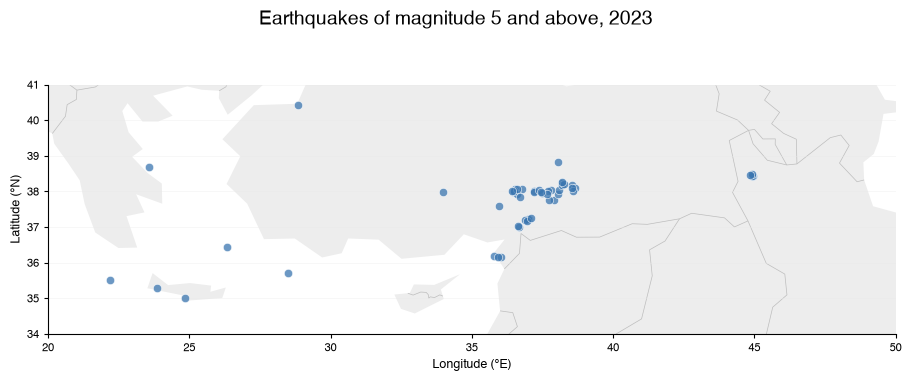

In [11]:
from datachart.constants import DRAW_POSITION

quakes = ScatterChart([{"x": lon, "y": lat} for _, lat, lon, _, _ in QUAKES])

Panel(
    # the order does not matter: the map sits below by its position
    [quakes, BasemapChart([BASEMAP_FEATURE.LAND, BASEMAP_FEATURE.BORDERS])],
    title="Earthquakes of magnitude 5 and above, 2023",
    xlabel="Longitude (°E)",
    ylabel_left="Latitude (°N)",
    aspect_ratio=ASPECT_RATIO.GEOGRAPHIC,
    figsize=(9.0, 3.8),
).show()

`DRAW_POSITION.ABOVE` draws the map over the marks instead, and still under reference lines and text notes. Its use is a map drawn as lines only, over a chart that would otherwise cover the coast: a hexbin fills its cells edge to edge, and a coastline above it keeps the reader oriented.

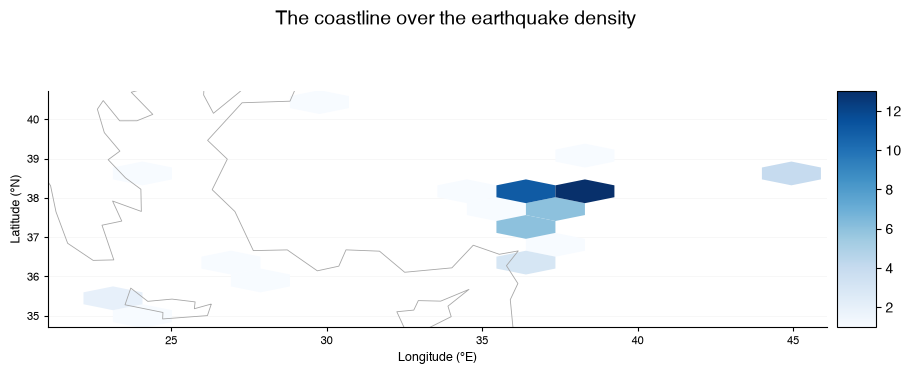

In [12]:
from datachart.charts import HexbinChart

Panel(
    [
        HexbinChart(
            {"x": [q[2] for q in QUAKES], "y": [q[1] for q in QUAKES]},
            gridsize=12,
            mincnt=1,
        ),
        BasemapChart(BASEMAP_FEATURE.COASTLINE, position=DRAW_POSITION.ABOVE),
    ],
    title="The coastline over the earthquake density",
    xlabel="Longitude (°E)",
    ylabel_left="Latitude (°N)",
    aspect_ratio=ASPECT_RATIO.GEOGRAPHIC,
    figsize=(9.0, 3.8),
).show()

## Real-World Examples

### Where did the strongest earthquakes of 2023 strike? (land and borders under a bubble scatter, geographic aspect, notes)

The first question of an earthquake report is where, and a coastline answers it better than bare coordinates. The land and the borders go under a scatter chart whose bubble size is the magnitude, at geographic proportions, so the reader sees at once that the largest events sit in south-eastern Türkiye near the Syrian border, and that the smaller ones follow the Hellenic arc south of Crete. A note names the Kahramanmaraş sequence.

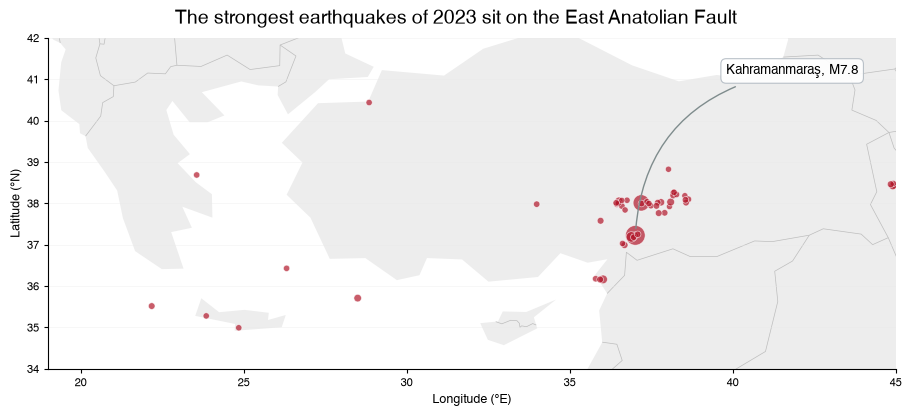

In [13]:
main = max(QUAKES, key=lambda quake: quake[4])

bubbles = ScatterChart(
    # the bubble area grows with the energy of the earthquake
    [
        {"x": lon, "y": lat, "size": 4 ** (magnitude - 4.3)}
        for _, lat, lon, _, magnitude in QUAKES
    ],
    style={"plot_scatter_color": "#b2182b", "plot_scatter_alpha": 0.7},
    texts={
        "text": f"Kahramanmaraş, M{main[4]:.1f}",
        # the note sits in the axes corner, so it stays put when the view narrows
        "x": 0.8,
        "y": 0.9,
        "coords": "axes",
        "target": (main[2], main[1]),
    },
)
land = BasemapChart([BASEMAP_FEATURE.LAND, BASEMAP_FEATURE.BORDERS])

Panel(
    [land, bubbles],
    title="The strongest earthquakes of 2023 sit on the East Anatolian Fault",
    xlabel="Longitude (°E)",
    ylabel_left="Latitude (°N)",
    aspect_ratio=ASPECT_RATIO.GEOGRAPHIC,
    figsize=(9.0, 4.0),
    **REGION,
).show()

### How far apart are the capitals of the European Union? (borders and lakes, point labels, geographic aspect)

A map of the member states' capitals shows at a glance how far the Union reaches: from Lisbon to Nicosia, and from Valletta to Helsinki. The coordinates are those of the 27 capital cities, rounded to a tenth of a degree. Each point carries its city's name, and the borders and lakes let the reader place the cities without a country fill.

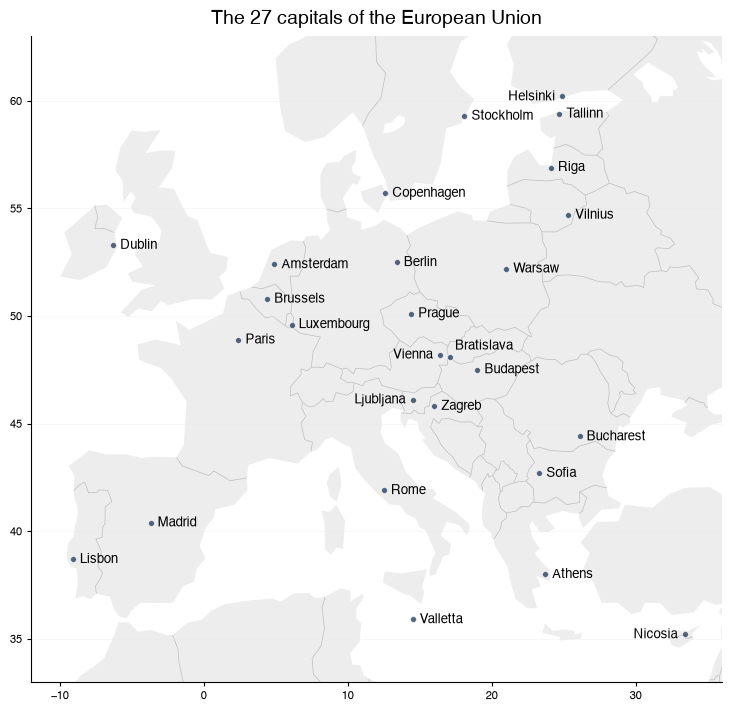

In [14]:
# (city, latitude, longitude), rounded to a tenth of a degree
CAPITALS = [
    ("Vienna", 48.2, 16.4), ("Brussels", 50.8, 4.4), ("Sofia", 42.7, 23.3),
    ("Zagreb", 45.8, 16.0), ("Nicosia", 35.2, 33.4), ("Prague", 50.1, 14.4),
    ("Copenhagen", 55.7, 12.6), ("Tallinn", 59.4, 24.7), ("Helsinki", 60.2, 24.9),
    ("Paris", 48.9, 2.4), ("Berlin", 52.5, 13.4), ("Athens", 38.0, 23.7),
    ("Budapest", 47.5, 19.0), ("Dublin", 53.3, -6.3), ("Rome", 41.9, 12.5),
    ("Riga", 56.9, 24.1), ("Vilnius", 54.7, 25.3), ("Luxembourg", 49.6, 6.1),
    ("Valletta", 35.9, 14.5), ("Amsterdam", 52.4, 4.9), ("Warsaw", 52.2, 21.0),
    ("Lisbon", 38.7, -9.1), ("Bucharest", 44.4, 26.1), ("Bratislava", 48.1, 17.1),
    ("Ljubljana", 46.1, 14.5), ("Madrid", 40.4, -3.7), ("Stockholm", 59.3, 18.1),
]

Panel(
    [
        BasemapChart(
            [BASEMAP_FEATURE.LAND, BASEMAP_FEATURE.BORDERS, BASEMAP_FEATURE.LAKES]
        ),
        ScatterChart(
            [{"x": lon, "y": lat, "label": city} for city, lat, lon in CAPITALS],
            style={"plot_scatter_color": "#1d3557", "plot_scatter_size": 18},
        ),
    ],
    title="The 27 capitals of the European Union",
    aspect_ratio=ASPECT_RATIO.GEOGRAPHIC,
    xmin=-12,
    xmax=36,
    ymin=33,
    ymax=63,
    figsize=(8.0, 7.0),
).show()

### How does the aftershock zone compare with the region? (limits, Grid)

A report often pairs the overview with a close-up. The same composed panel, drawn twice with different limits, gives both, and [Grid](../../utility/grid/) arranges them side by side. The map follows the limits, because it is drawn in the same coordinates as the bubbles; the close-up shows the Kahramanmaraş sequence lined up along the fault, just north of the Syrian border.

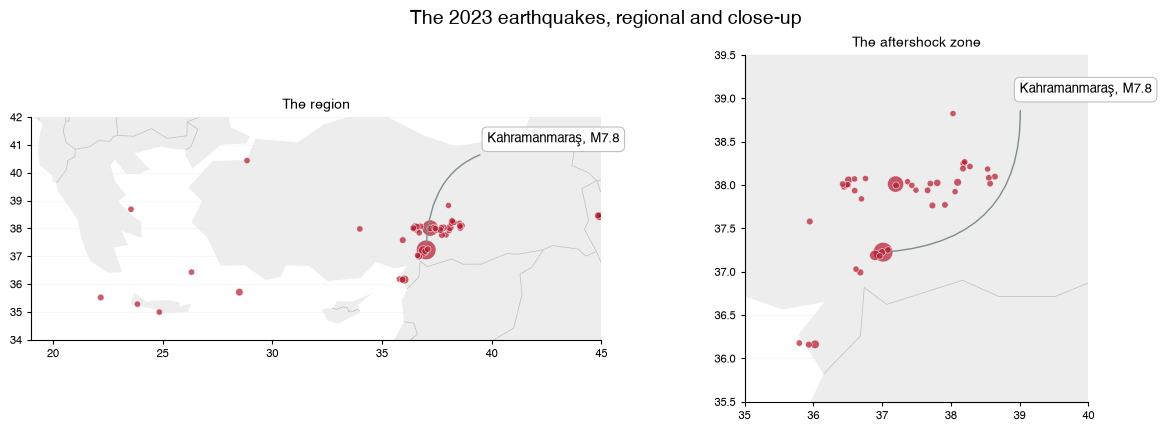

In [15]:
from datachart.utils import Grid

overview = Panel(
    [land, bubbles], title="The region", aspect_ratio=ASPECT_RATIO.GEOGRAPHIC, **REGION
)
closeup = Panel(
    [land, bubbles],
    title="The aftershock zone",
    aspect_ratio=ASPECT_RATIO.GEOGRAPHIC,
    # narrow the axes to the mainshocks; the map follows
    xmin=35,
    xmax=40,
    ymin=35.5,
    ymax=39.5,
)

Grid(
    [[overview, closeup]],
    title="The 2023 earthquakes, regional and close-up",
    figsize=(12.0, 4.2),
).show()